#### This is the alternative notebook as few models require large time for training, while that training period i code over here.

### Importing libraries

In [2]:
import sys
sys.path.append('..')

import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
import numpy as np
from src.data_prep import clean_data, feature_engineering, split_features_target
from src.pipeline import build_preprocessor, build_pipeline
from src.train import stratified_split, train_and_save_model
from src.evaluate import evaluate_model, reg_graph
from src.utils import log_info

In [4]:
log_info("Loading dataset...")
df = pd.read_csv("../data/vehicle_price_prediction.csv")

2025-09-19 16:43:45,447 - INFO - Loading dataset...


In [5]:
log_info(f"Initial dataset shape: {df.shape}")

2025-09-19 16:43:47,332 - INFO - Initial dataset shape: (1000000, 20)


In [6]:
log_info("Cleaning data...")
df = clean_data(df)
df = feature_engineering(df)

log_info(f"Data after cleaning & feature engineering: {df.shape}")

2025-09-19 16:43:47,342 - INFO - Cleaning data...
2025-09-19 16:43:50,065 - INFO - Data after cleaning & feature engineering: (1000000, 22)


In [7]:
X, y = split_features_target(df, target="price_log")

In [8]:
preprocessor = build_preprocessor(X)

In [9]:
log_info("Performing stratified train-test split...")
X_train, X_test, y_train, y_test = stratified_split(
    X, y, stratify_col=pd.cut(X["vehicle_age"], bins=[0,5,10,15,20,50])
)

log_info(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

2025-09-19 16:43:50,347 - INFO - Performing stratified train-test split...
2025-09-19 16:43:57,632 - INFO - Train size: (800000, 20), Test size: (200000, 20)


## KNN Regressor

In [10]:
from sklearn.neighbors import KNeighborsRegressor
log_info("K-Nearest Neighbors Regressor...")
knn_model = KNeighborsRegressor(n_neighbors=5, weights='uniform', algorithm='auto')
knn_pipeline = build_pipeline(preprocessor, knn_model)

2025-09-19 16:43:57,645 - INFO - K-Nearest Neighbors Regressor...


In [11]:
log_info("Training and saving the KNN model...")
train_and_save_model(knn_pipeline, X_train, y_train, model_path="../models/knn_model.pkl")

2025-09-19 16:43:57,657 - INFO - Training and saving the KNN model...


Model saved to ../models/knn_model.pkl


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['mileage', 'engine_hp',
                                                   'owner_count', 'vehicle_age',
                                                   'brand_popularity',
                                                   'price_per_hp',
                                                   'is_luxury_brand',
                                                   'condition_encoded']),
                                                 ('cat_low',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['transmission', 'fuel_type',
                                                   'drivetrain', 'body_type',
                                                   'seller_type']),
                                                 ('cat_high',
                                                  Pipeline(steps=[('target_encoder',
                                                                   TargetEncoder())]),
                                                  ['make', 'model', 'trim',
                                                   'exterior_color',
                                                   'interior_color'])])),
                ('model', KNeighborsRegressor())])

In [13]:
log_info("Evaluating the knn model...")
knn_results = evaluate_model(knn_pipeline, X_test, y_test)
log_info(f"KNN Results: \n{knn_results}")

2025-09-19 16:49:46,878 - INFO - Evaluating the knn model...
2025-09-19 16:56:17,378 - INFO - KNN Results: 
      RMSE       MAE        R2      MAPE
0  0.11423  0.078649  0.982362  0.850648


2025-09-19 16:58:24,790 - INFO - Reg graph for KNN model...


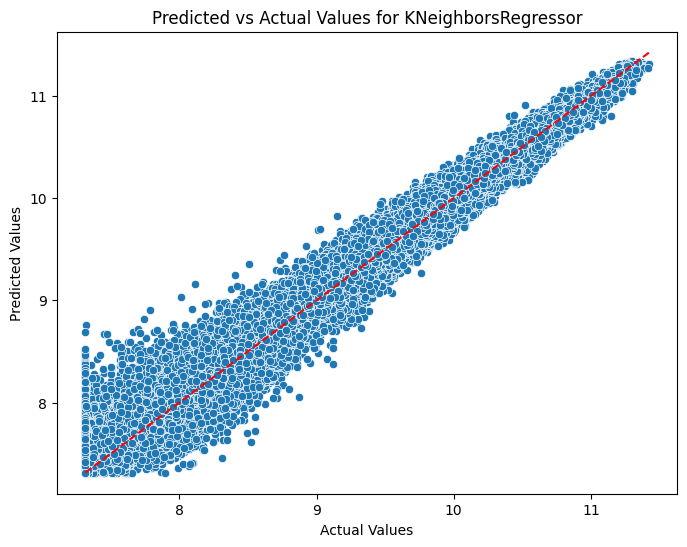

In [15]:
log_info("Reg graph for KNN model...")
reg_graph(knn_pipeline, X_test, y_test)

## Random Forest Regressor

In [16]:
from sklearn.ensemble import RandomForestRegressor
log_info("Random Forest Regressor...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_pipeline = build_pipeline(preprocessor, rf_model)

2025-09-19 17:05:29,466 - INFO - Random Forest Regressor...


In [17]:
log_info("Training and saving the Random Forest model...")
train_and_save_model(rf_pipeline, X_train, y_train, model_path="../models/rf_model.pkl")

2025-09-19 17:05:53,191 - INFO - Training and saving the Random Forest model...


Model saved to ../models/rf_model.pkl


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['mileage', 'engine_hp',
                                                   'owner_count', 'vehicle_age',
                                                   'brand_popularity',
                                                   'price_per_hp',
                                                   'is_luxury_brand',
                                                   'condition_encoded']),
                                                 ('cat_low',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['transmission', 'fuel_type',
                                                   'drivetrain', 'body_type',
                                                   'seller_type']),
                                                 ('cat_high',
                                                  Pipeline(steps=[('target_encoder',
                                                                   TargetEncoder())]),
                                                  ['make', 'model', 'trim',
                                                   'exterior_color',
                                                   'interior_color'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [18]:
log_info("Evaluating the model...")
rf_results = evaluate_model(rf_pipeline, X_test, y_test)
log_info(f"Random Forest Results: \n{rf_results}")

2025-09-19 17:35:21,029 - INFO - Evaluating the model...
2025-09-19 17:36:02,016 - INFO - Random Forest Results: 
     RMSE       MAE        R2      MAPE
0  0.0041  0.001221  0.999977  0.012751


2025-09-19 17:43:42,919 - INFO - Reg graph for Random Forest model...


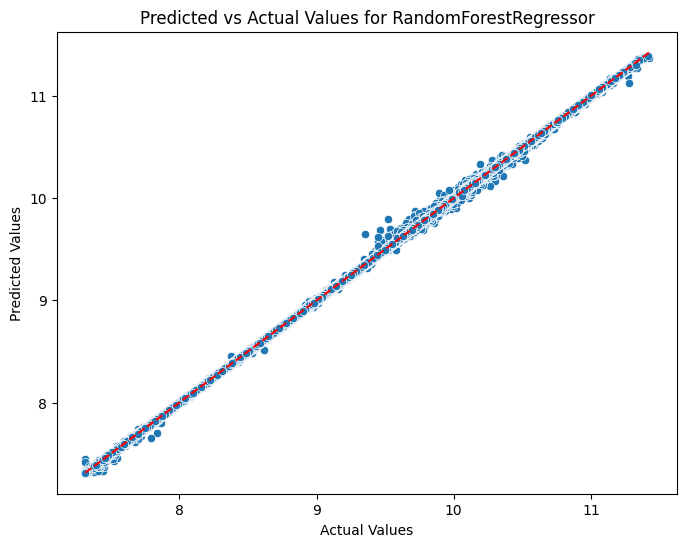

In [22]:
log_info("Reg graph for Random Forest model...")
reg_graph(rf_pipeline, X_test, y_test)

## XG Boost Regressor

In [19]:
log_info("XG Boost Regressor...")
from xgboost import XGBRegressor
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_pipeline = build_pipeline(preprocessor, xgb_model)

2025-09-19 17:40:24,695 - INFO - XG Boost Regressor...


In [20]:
log_info("Training and saving the XG Boost model...")
train_and_save_model(xgb_pipeline, X_train, y_train, model_path="../models/xgb_model.pkl")

2025-09-19 17:40:54,638 - INFO - Training and saving the XG Boost model...


Model saved to ../models/xgb_model.pkl


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['mileage', 'engine_hp',
                                                   'owner_count', 'vehicle_age',
                                                   'brand_popularity',
                                                   'price_per_hp',
                                                   'is_luxury_brand',
                                                   'condition_encoded']),
                                                 ('cat_low',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='mos...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=100, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [21]:
log_info("Evaluating XG Boost model...")
xgb_results = evaluate_model(xgb_pipeline, X_test, y_test)
log_info(f"XG Boost Results: \n{xgb_results}")

2025-09-19 17:42:38,042 - INFO - Evaluating XG Boost model...
2025-09-19 17:42:38,746 - INFO - XG Boost Results: 
       RMSE       MAE       R2      MAPE
0  0.012749  0.009066  0.99978  0.095599


2025-09-19 17:45:54,653 - INFO - Reg graph for XG Boost model...


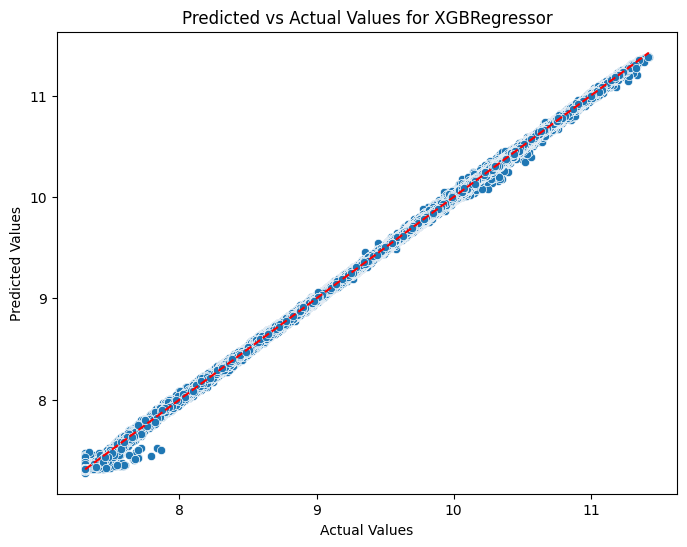

In [24]:
log_info("Reg graph for XG Boost model...")
reg_graph(xgb_pipeline, X_test, y_test)

In [30]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
log_info("Support Vector Regressor...")

svr_model = SVR()
svr_pipeline = build_pipeline(preprocessor, svr_model)  

param_grid = {
    'model__C': [0.1, 1, 10],
    'model__epsilon': [0.01, 0.1, 1],
    'model__kernel': ['rbf']
}

grid = GridSearchCV(
    svr_pipeline,
    param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1
)
train_and_save_model(grid, X_train, y_train, model_path="../models/svr_model.pkl")

2025-09-19 18:38:10,486 - INFO - Support Vector Regressor...


KeyboardInterrupt: 